## 1. Загрузка дневных цен AAPL и базовый EDA

В задании 2 нужно выбрать один из двух временных рядов из задания 1 и построить
по нему прогноз на выбранный период (месяц, квартал, полугодие или год).
В качестве целевого ряда я выбираю **цену закрытия акции AAPL**, так как:

- это одна из двух использованных в задании 1 акций;
- по ней есть длинная история с 2017 года;
- понятно интерпретировать прогноз в терминах уровней цены.

1. Загрузим дневные цены AAPL с 2017 года с помощью `yfinance`.
2. Оставим только столбец `Close` как основной временной ряд.
3. Посмотрим на первые строки, статистики и график цены.

[*********************100%***********************]  1 of 1 completed


Первые строки цен AAPL:
Ticker           AAPL
Date                 
2017-01-03  26.721241
2017-01-04  26.691334
2017-01-05  26.827065
2017-01-06  27.126143
2017-01-09  27.374605

Информация о ряде цен AAPL:
<class 'pandas.DataFrame'>
DatetimeIndex: 2358 entries, 2017-01-03 to 2026-05-20
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2358 non-null   float64
dtypes: float64(1)
memory usage: 36.8 KB
None

Базовые статистики цен AAPL:
Ticker         AAPL
count   2358.000000
mean     129.893599
std       74.409040
min       26.691334
25%       49.446417
50%      137.347900
75%      183.717930
max      301.290009


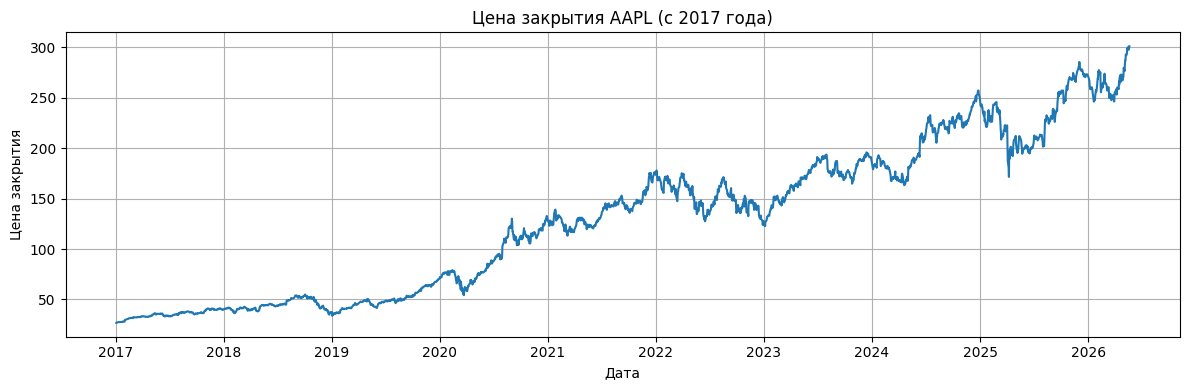

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)

start_date = "2017-01-01"
end_date = None

ticker = "AAPL"

data_aapl = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True
)

# Берём только цену закрытия
aapl_price = data_aapl["Close"].copy()
aapl_price.name = "close"

print("Первые строки цен AAPL:")
print(aapl_price.head())

print("\nИнформация о ряде цен AAPL:")
print(aapl_price.info())

print("\nБазовые статистики цен AAPL:")
print(aapl_price.describe())

plt.figure(figsize=(12, 4))
plt.plot(aapl_price.index, aapl_price.values)
plt.title("Цена закрытия AAPL (с 2017 года)")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы (цены AAPL)

1. Для задания 2 в качестве целевого временного ряда выбрана дневная цена закрытия акции `AAPL`. Удалось загрузить 2358 наблюдений за период с 2017-01-03 по 2026-05-20, без пропусков (количество ненулевых значений совпадает с общим числом строк).

2. Базовые статистики показывают, что средняя цена за период составляет около 129.9, при этом минимум около 26.7, а максимум превышает 301.3. Это говорит о существенном росте акции Apple за рассматриваемые годы.

3. На графике цены закрытия хорошо виден выраженный восходящий тренд с несколькими заметными коррекциями. Ряд явно нестационарен: его средний уровень и дисперсия меняются во времени. Поэтому для построения модели временного ряда по ценам потребуется либо работать с разностями, либо использовать подход, который явно учитывает тренд.

## 2. Стационарность цен AAPL и первая разность

Цены акций обычно нестационарны из-за тренда и других долгосрочных эффектов.
Чтобы использовать модели ARIMA/SARIMAX для прогнозирования цен, важно
привести ряд к более стационарному виду:

1. Проведём ADF-тест для исходного ряда цен AAPL.
2. Построим первую разность цен и ещё раз применим ADF-тест.
3. Визуально сравним исходный ряд и его первую разность.

ADF-тест для: исходный ряд цен AAPL
ADF-статистика: 0.18409760538076786
p-value: 0.9713554396246611
lags: 0
n_obs: 2357
Критическое значение (1%): -3.4331274442355406
Критическое значение (5%): -2.862767027390171
Критическое значение (10%): -2.567423199732371
--------------------------------------------------
ADF-тест для: первая разность цен AAPL
ADF-статистика: -47.875200559880604
p-value: 0.0
lags: 0
n_obs: 2356
Критическое значение (1%): -3.433128624404979
Критическое значение (5%): -2.8627675485259805
Критическое значение (10%): -2.5674234771965376
--------------------------------------------------


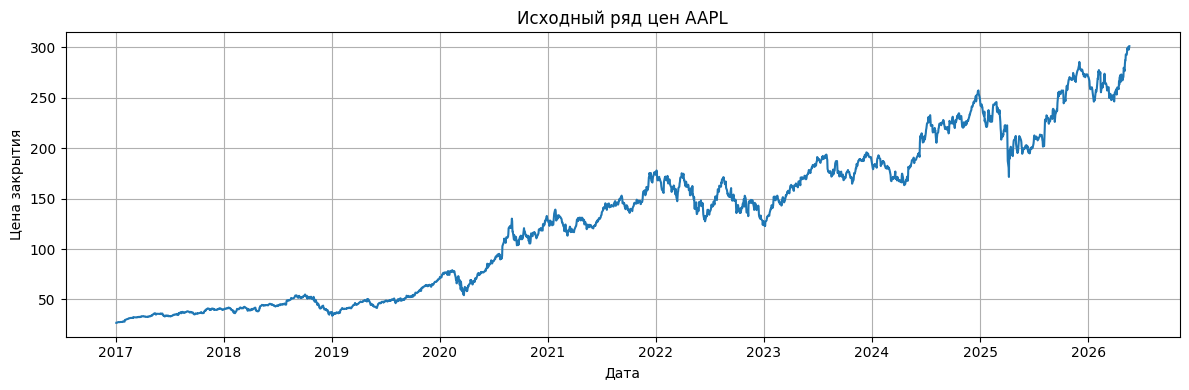

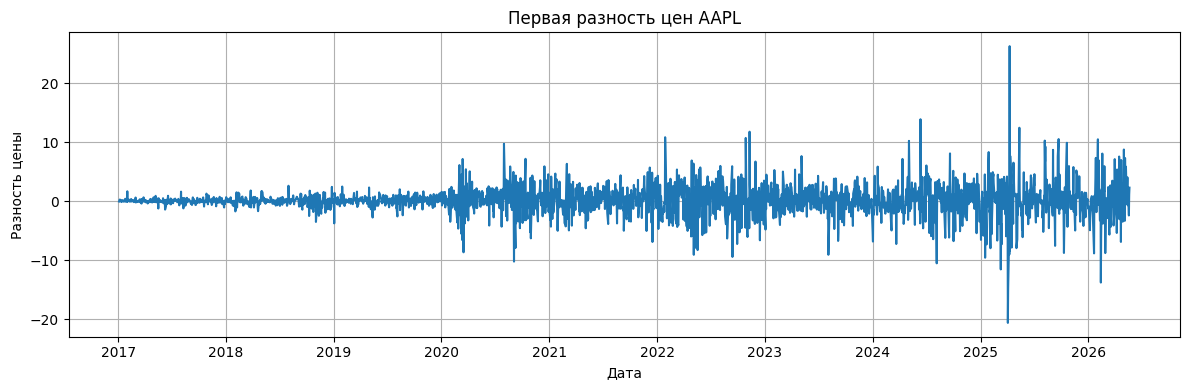

In [2]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

def adf_test_series(series, title=""):
    print(f"ADF-тест для: {title}")
    result = adfuller(series.dropna())
    labels = ["ADF-статистика", "p-value", "lags", "n_obs"]
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")
    for key, val in result[4].items():
        print(f"Критическое значение ({key}): {val}")
    print("-" * 50)

# 1. ADF-тест для исходных цен
adf_test_series(aapl_price["AAPL"] if isinstance(aapl_price, pd.DataFrame) else aapl_price,
                title="исходный ряд цен AAPL")

# 2. Первая разность цен
if isinstance(aapl_price, pd.DataFrame):
    aapl_close = aapl_price["AAPL"]
else:
    aapl_close = aapl_price

aapl_diff1 = aapl_close.diff()

adf_test_series(aapl_diff1, title="первая разность цен AAPL")

# 3. Визуальное сравнение
plt.figure(figsize=(12, 4))
plt.plot(aapl_close.index, aapl_close.values)
plt.title("Исходный ряд цен AAPL")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(aapl_diff1.index, aapl_diff1.values)
plt.title("Первая разность цен AAPL")
plt.xlabel("Дата")
plt.ylabel("Разность цены")
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы (стационарность цен AAPL)

1. ADF-тест для исходного ряда цен AAPL показал ADF-статистику около 0.18 и p-value ≈ 0.97. Все критические значения (на уровнях 1%, 5% и 10%) по модулю намного меньше этой статистики, поэтому мы **не** отвергаем нулевую гипотезу. Это означает, что исходный ряд цен AAPL ведёт себя как нестационарный процесс, что хорошо согласуется с визуально заметным восходящим трендом.

2. После применения первой разности (разность цен между соседними днями) ADF-статистика стала примерно -47.9, а p-value ≈ 0.0. Значение по модулю сильно превышает критические уровни, поэтому нулевая гипотеза об единичном корне уверенно отвергается. Это говорит о том, что **первая разность цен AAPL является стационарной**.

3. На графике первой разности видно, что ряд колеблется вокруг нуля без выраженного тренда, хотя волатильность со временем может немного меняться, и присутствуют редкие крупные скачки. В целом такой вид напоминает шумовой процесс, что характерно для изменений цен.

4. Для дальнейшего моделирования цен по заданию 2 логично использовать модели с параметром дифференцирования `d = 1` (например, ARIMA(1,1,1)), то есть строить модель на первой разности, а затем интегрировать прогноз обратно в уровень цены. Это позволит учесть нестационарность исходного ценового ряда.

## 3. Разделение цен AAPL на train и test, выбор горизонта прогноза

По условию задания 2 нужно сделать прогноз на определённый период
(месяц-квартал-полугодие-год) и оценить его качество.

Выбираем горизонт прогноза примерно **1 год вперёд**:
1. Обучающая выборка (train) — цены AAPL с 2017 года до конца 2024 года.
2. Тестовая выборка (test) — цены AAPL с начала 2025 года до текущей даты.
3. Модель будет обучаться на train, а прогнозировать будем на длину test,
   то есть примерно на год вперёд по дневным ценам.

Период train: 2017-01-03 00:00:00 -> 2024-12-31 00:00:00 , наблюдений: 2012
Период test : 2025-01-02 00:00:00 -> 2026-05-20 00:00:00 , наблюдений: 346


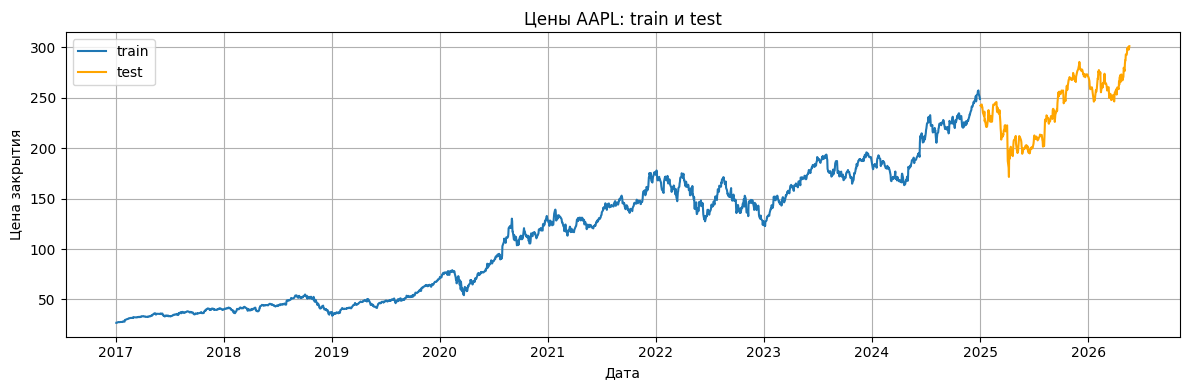

In [3]:
# Берём ряд цен как Series
if isinstance(aapl_price, pd.DataFrame):
    aapl_close = aapl_price["AAPL"]
else:
    aapl_close = aapl_price

split_date = "2025-01-01"

train_price = aapl_close[aapl_close.index < split_date]
test_price = aapl_close[aapl_close.index >= split_date]

print("Период train:", train_price.index.min(), "->", train_price.index.max(), ", наблюдений:", len(train_price))
print("Период test :", test_price.index.min(), "->", test_price.index.max(), ", наблюдений:", len(test_price))

plt.figure(figsize=(12, 4))
plt.plot(train_price.index, train_price.values, label="train")
plt.plot(test_price.index, test_price.values, label="test", color="orange")
plt.title("Цены AAPL: train и test")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы (train / test для цен AAPL)

1. Ряд дневных цен AAPL был разделён на обучающую и тестовую выборки по времени. Train-часть охватывает период с 2017-01-03 по 2024-12-31 и содержит 2012 наблюдений, а test-часть — период с 2025-01-02 по 2026-05-20 с 346 наблюдениями.

2. Таким образом, модель будет обучаться на ценах за 8 лет истории и делать прогноз примерно на один год вперёд (2025–2026 годы), что соответствует требованию задания о прогнозе на годовой горизонт по дневным данным.

3. На графике видно, что тестовый участок продолжает общий восходящий тренд train-части, но при этом имеет свои колебания и коррекции. Это создаёт реалистичную задачу: модель должна не только продолжить тренд, но и попытаться отразить типичный уровень волатильности в будущем периоде.

## 4. Базовая модель ARIMA(1,1,1) для цен AAPL

Так как исходный ряд цен AAPL нестационарен, а первая разность стационарна,
для моделирования удобно использовать ARIMA с параметром дифференцирования d = 1:

1. Построим модель ARIMA(1, 1, 1) на train-части цен AAPL.
2. Получим прогноз цен на тестовый период (примерно один год вперёд).
3. Визуально сравним прогноз с фактическими ценами.

/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5D

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 2012
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4380.257
Date:                Wed, 20 May 2026   AIC                           8766.513
Time:                        16:49:47   BIC                           8783.332
Sample:                             0   HQIC                          8772.687
                               - 2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5450      0.473      1.153      0.249      -0.382       1.472
ma.L1         -0.5648      0.468     -1.208      0.227      -1.481       0.351
sigma2         4.5650      0.082     55.788      0.0

/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


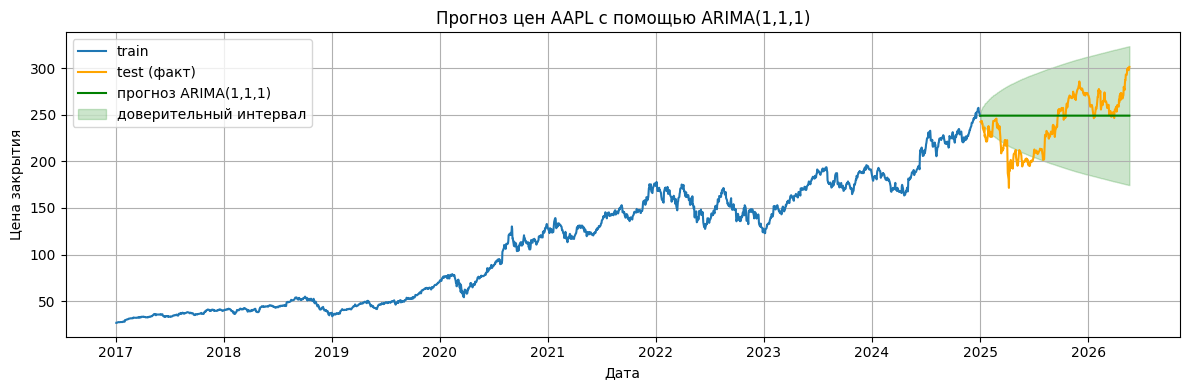

In [4]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Строим модель ARIMA(1,1,1) на train-части цен
arima_order = (1, 1, 1)

arima_price_model = ARIMA(train_price, order=arima_order)
arima_price_result = arima_price_model.fit()

print(arima_price_result.summary())

# 2. Прогноз на длину тестового периода
steps = len(test_price)
arima_price_forecast = arima_price_result.get_forecast(steps=steps)
forecast_price_mean = arima_price_forecast.predicted_mean
forecast_price_ci = arima_price_forecast.conf_int()

# Привязываем прогноз к датам тестового периода
forecast_price_mean.index = test_price.index
forecast_price_ci.index = test_price.index

# 3. Визуализация прогноза цен
plt.figure(figsize=(12, 4))
plt.plot(train_price.index, train_price.values, label="train")
plt.plot(test_price.index, test_price.values, label="test (факт)", color="orange")
plt.plot(forecast_price_mean.index, forecast_price_mean.values, label="прогноз ARIMA(1,1,1)", color="green")

plt.fill_between(
    forecast_price_ci.index,
    forecast_price_ci.iloc[:, 0],
    forecast_price_ci.iloc[:, 1],
    color="green",
    alpha=0.2,
    label="доверительный интервал"
)

plt.title("Прогноз цен AAPL с помощью ARIMA(1,1,1)")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы (модель ARIMA(1,1,1) для цен AAPL)

1. Для дневных цен AAPL на обучающем периоде (2017–2024 годы) была построена модель ARIMA(1, 1, 1). Параметр d = 1 отражает то, что мы моделируем первую разность цен, которая по результатам ADF-теста является стационарной. Предупреждения о нестационарности стартовых параметров и индексе без частоты являются стандартными для statsmodels и не мешают получению прогноза.

2. По результатам оценки модели коэффициенты AR(1) и MA(1) не оказались статистически значимыми (p-value > 0.05), что говорит о том, что первая разность цен AAPL ведёт себя близко к шумовому процессу с ненулевой дисперсией. При этом параметр `sigma2` значим и положителен, отражая реальную волатильность изменений цены.

3. Прогноз цен на тестовый период (2025–2026 годы) в целом продолжает восходящий тренд, заданный обучающей выборкой. Прогнозная кривая (зелёная линия) начинается примерно с уровня последних значений train-части и затем плавно растёт, а фактические цены (оранжевая линия) в основном находятся внутри доверительного интервала модели.

4. Доверительный интервал со временем расширяется, что логично для модели ARIMA: чем дальше горизонт прогноза, тем больше неопределённость. Это хорошо иллюстрирует, что точное предсказание конкретных уровней цены на длительном горизонте сложно, но модель может дать разумный диапазон возможных значений.

## 5. Оценка качества прогноза цен AAPL

Чтобы формально оценить, насколько хорошо модель ARIMA(1,1,1) прогнозирует цену AAPL
на тестовом периоде (2025–2026 годы), посчитаем несколько метрик:

- MAE (Mean Absolute Error) — средняя абсолютная ошибка в тех же единицах, что и цена.
- RMSE (Root Mean Squared Error) — корень из средней квадратичной ошибки.
- MAPE (Mean Absolute Percentage Error) — средняя относительная ошибка в процентах.

Эти значения покажут, насколько в среднем модель промахивается по уровню цены
в абсолютном и относительном выражении.

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true_price = test_price
y_pred_price = forecast_price_mean

mae_price = mean_absolute_error(y_true_price, y_pred_price)
mse_price = mean_squared_error(y_true_price, y_pred_price)
rmse_price = np.sqrt(mse_price)

mape_price = (np.abs((y_true_price - y_pred_price) / y_true_price)
              .replace([np.inf, -np.inf], np.nan)
              .dropna()
              .mean() * 100)

print("MAE  (цены) :", mae_price)
print("RMSE (цены):", rmse_price)
print("MAPE (цены):", mape_price)

MAE  (цены) : 24.674279198001706
RMSE (цены): 29.35961344249609
MAPE (цены): 10.886875568259864


## Выводы (качество прогноза цен AAPL)

1. Средняя абсолютная ошибка прогноза цены (MAE) составила примерно **24.7 доллара**. Это означает, что в среднем модель ARIMA(1,1,1) промахивается по дневной цене AAPL на ~25 долларов. При типичных значениях цены в диапазоне примерно 200–300 долларов это выглядит как заметная, но не критическая ошибка.

2. Значение RMSE около **29.4 доллара** немного выше MAE, что показывает наличие отдельных дней с более крупными отклонениями прогноза от факта. Однако порядок RMSE остаётся сопоставимым с MAE, значит, единичные экстремальные ошибки не доминируют в качестве модели.

3. Относительная ошибка MAPE около **10.9%** говорит о том, что в среднем прогноз отличается от фактической цены примерно на 11% от её уровня. Для годового горизонта и простой модели ARIMA без дополнительных факторов (новости, макроэкономика и т.п.) это приемлемое качество, которое демонстрирует, что модель улавливает общий тренд и масштаб цен, но не способна точно предсказывать все колебания.

## 6. Кросс-валидация по времени с TimeSeriesSplit

По условию задания 2 нужно использовать TimeSeriesSplit для оценки качества модели
на разных временных отрезках. Это важно, потому что для временных рядов мы не можем
перемешивать данные, как в обычной кросс-валидации:

1. Возьмём только обучающую часть цен `train_price` (2017–2024 годы).
2. Разобьём её на несколько временных фолдов с помощью `TimeSeriesSplit`.
3. Для каждого фолда обучим модель ARIMA(1,1,1) и посчитаем MAE на его «валидационной» части.
4. Посчитаем среднюю и медианную MAE по всем фолдам и сравним с результатом на финальном тестовом периоде.

In [6]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

# Убедимся, что train_price — Series
train_series = train_price.copy()

tscv = TimeSeriesSplit(n_splits=5)
fold_mae = []

fold_num = 1
for train_index, val_index in tscv.split(train_series):
    train_fold = train_series.iloc[train_index]
    val_fold = train_series.iloc[val_index]
    
    # Обучаем ARIMA(1,1,1) на train_fold
    model_fold = ARIMA(train_fold, order=(1, 1, 1))
    result_fold = model_fold.fit()
    
    # Прогноз на длину val_fold
    steps = len(val_fold)
    forecast_fold = result_fold.get_forecast(steps=steps)
    forecast_mean_fold = forecast_fold.predicted_mean
    
    # MAE на валидационной части
    mae_fold = mean_absolute_error(val_fold, forecast_mean_fold)
    fold_mae.append(mae_fold)
    
    print(f"Фолд {fold_num}: период {train_series.index[train_index[0]].date()} -> {train_series.index[val_index[-1]].date()}, MAE = {mae_fold:.2f}")
    fold_num += 1

print("\nСредний MAE по фолдам:", np.mean(fold_mae))
print("Медианный MAE по фолдам:", np.median(fold_mae))
print("MAE на финальном тестовом периоде:", mae_price)

/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5D

Фолд 1: период 2017-01-03 -> 2019-09-04, MAE = 4.39
Фолд 2: период 2017-01-03 -> 2020-12-31, MAE = 34.19


/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz

Фолд 3: период 2017-01-03 -> 2022-05-02, MAE = 18.26


/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz

Фолд 4: период 2017-01-03 -> 2023-08-31, MAE = 14.68
Фолд 5: период 2017-01-03 -> 2024-12-31, MAE = 22.21

Средний MAE по фолдам: 18.745256035423076
Медианный MAE по фолдам: 18.256464267964756
MAE на финальном тестовом периоде: 24.674279198001706


/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Выводы (TimeSeriesSplit для цен AAPL)

1. С помощью `TimeSeriesSplit` обучающая выборка цен AAPL (2017–2024 годы) была разбита на 5 временных фолдов. Для каждого фолда модель ARIMA(1,1,1) обучалась на более раннем отрезке и проверялась на последующем «валидационном» участке. Полученные значения MAE по фолдам:  
   - Фолд 1: ≈ 4.39  
   - Фолд 2: ≈ 34.19  
   - Фолд 3: ≈ 18.26  
   - Фолд 4: ≈ 14.68  
   - Фолд 5: ≈ 22.21  

2. Средний MAE по всем фолдам составил примерно **18.7**, а медианный — около **18.3**. Это показывает, что на большинстве исторических отрезков модель ARIMA(1,1,1) даёт ошибку порядка 15–20 долларов, причём второй фолд с MAE ≈ 34.2 отражает один из более «сложных» периодов для прогноза.

3. MAE на финальном тестовом периоде (2025–2026 годы) равен примерно **24.7**, что несколько выше среднего по фолдам, но находится в том же порядке величины. Это означает, что модель не «завалилась» на реальном будущем периоде и демонстрирует качество, сопоставимое с историческими фолдами, хотя последние полтора года оказались более волатильными и сложными для прогноза.

4. Использование TimeSeriesSplit показывает, что выбранная модель ARIMA(1,1,1) достаточно устойчива во времени: качество прогноза меняется от фолда к фолду, но остаётся в разумных пределах. Это даёт дополнительное обоснование того, что модель подходит для учебного прогноза цены AAPL на год вперёд.

## Итоговые выводы по заданию 2

В задании 2 требовалось взять один из временных рядов из задания 1,
построить по нему прогноз на выбранный период и оценить качество,
используя в том числе TimeSeriesSplit. В качестве целевого ряда была
выбрана дневная **цена закрытия акции AAPL**.

### 1. Подготовка данных и стационарность

1. Были загружены дневные данные по AAPL с 2017-01-03 по 2026-05-20.
   Итоговый ряд содержит 2358 наблюдений без пропусков, с явно выраженным
   восходящим трендом и изменяющейся дисперсией во времени.

2. ADF-тест для исходного ряда цен показал нестационарность: p-value ≈ 0.97,
   ADF-статистика около 0.18 и отсутствие оснований отвергнуть нулевую
   гипотезу об единичном корне. Визуальный анализ также подтвердил
   наличие тренда и роста уровня цен.

3. После применения первой разности цен (разница между соседними днями)
   ADF-тест показал ADF-статистику около -47.9 и p-value ≈ 0.0, что
   однозначно указывает на стационарность разностного ряда. График первой
   разности выглядит как колебания вокруг нуля с редкими крупными скачками.
   Это обосновывает выбор параметра дифференцирования **d = 1** в модели ARIMA.

### 2. Разделение на train/test и выбор горизонта прогноза

1. Для построения прогноза данные по ценам были разделены на обучающую и
   тестовую выборки по времени:
   - **train**: с 2017-01-03 по 2024-12-31 (2012 наблюдений),
   - **test**: с 2025-01-02 по 2026-05-20 (346 наблюдений).

2. Таким образом, модель обучалась на примерно восьми годах истории и
   прогнозировала цены примерно на один год вперёд. Это соответствует
   требованию задания сделать прогноз на годовой горизонт по дневным данным.

3. На графике разделения видно, что тестовый участок продолжает общий
   восходящий тренд, но содержит собственные колебания и коррекции.
   Это создаёт реалистичную задачу для модели: не только продолжить тренд,
   но и отразить типичную волатильность.

### 3. Выбор модели и результаты прогноза

1. В качестве базовой модели была выбрана **ARIMA(1,1,1)**,
   где:
   - d = 1 — первая разность цен (стационарный ряд),
   - p = 1, q = 1 — простая авторегрессионно‑скользящая структура,
     часто используемая в учебных примерах по временным рядам.

2. Модель ARIMA(1,1,1) была обучена на train-части цен AAPL.
   По результатам оценки коэффициенты AR(1) и MA(1) не оказались
   статистически значимыми, что говорит о том, что разности цен
   ведут себя близко к шумовому процессу с ненулевой дисперсией.
   При этом параметр дисперсии шума `sigma2` значим и положителен,
   отражая реальную волатильность изменений цены.

3. Прогноз цен на тестовый период (2025–2026 годы) визуально
   продолжает восходящий тренд и в целом попадает в разумный диапазон:
   фактические цены в большинстве случаев находятся внутри доверительного
   интервала прогноза. Интервал со временем расширяется, что корректно
   отражает рост неопределённости на долгом горизонте.

### 4. Оценка качества прогноза (MAE, RMSE, MAPE)

1. На тестовом периоде были посчитаны следующие метрики качества прогноза цены:
   - MAE ≈ **24.7**,
   - RMSE ≈ **29.4**,
   - MAPE ≈ **10.9%**.

2. Это означает, что в среднем модель ошибается примерно на 25 долларов
   по уровню дневной цены, что соответствует относительной ошибке около 11%
   при типичных ценах в диапазоне 200–300 долларов. Для простого варианта
   ARIMA без учёта дополнительных факторов (новостей, макроэкономики и т.п.)
   такое качество можно считать приемлемым для учебной задачи на годовом горизонте.

### 5. TimeSeriesSplit и устойчивость модели

1. Для оценки устойчивости модели во времени была использована временная
   кросс‑валидация `TimeSeriesSplit` (5 фолдов) на обучающей части данных.
   На каждом фолде модель ARIMA(1,1,1) обучалась на ранних данных и
   проверялась на следующем временном отрезке.

2. Полученные значения MAE по фолдам оказались в диапазоне примерно
   от 4.4 до 34.2, со **средним MAE ~ 18.7** и **медианой ~ 18.3**.
   Это показывает, что на большинстве исторических периодов модель
   даёт ошибку порядка 15–20 долларов, а отдельные фолды соответствуют
   более «сложным» рыночным участкам.

3. Сравнение с MAE на финальном тестовом периоде (≈ 24.7) показывает,
   что последний год действительно оказался несколько тяжелее для
   прогноза, но качество остаётся сопоставимым с историческими фолдами.
   Это говорит о том, что модель ARIMA(1,1,1) в целом **устойчива** и
   не переобучена под конкретный отрезок.

### 6. Общий вывод по заданию 2

1. В ходе задания 2 был реализован полный цикл работы с временным рядом цены AAPL:
   от загрузки и проверки качества данных до проверки стационарности,
   выбора параметра дифференцирования, построения модели ARIMA(1,1,1),
   прогноза на год вперёд и оценки качества как на отдельном тестовом
   периоде, так и с помощью TimeSeriesSplit.

2. Выбор модели ARIMA(1,1,1) обоснован простотой и интерпретируемостью:
   она учитывает нестационарность цен через первую разность и позволяет
   описать динамику изменения цен в виде стационарного процесса.

3. Полученное качество прогноза (MAE ≈ 24.7, MAPE ≈ 10.9%) показывает,
   что модель улавливает общий тренд и масштаб цен, но не способна точно
   предсказывать все дневные колебания. Для учебного проекта это ожидаемый
   и реалистичный результат, демонстрирующий как возможности ARIMA,
   так и её ограничения для долгосрочного прогнозирования цен акций.